# Analyzing Public Perception of DeepSeek on Reddit: A Text-Based Exploration

# Introduction

The rise of DeepSeek and other large language models (LLMs) marks both a technological milestone and an opportunity to explore the geopolitical and cultural tensions in the global AI landscape. It is important to examine how predominantly English-speaking social media platforms, particularly Reddit, shape perceptions of AI models like DeepSeek (developed in China) and ChatGPT (developed in the U.S.). In this task, we ask the question: **What narratives emerge from Reddit communities’ discussions about DeepSeek, and how do these narratives reflect user perceptions and sentiment of AI innovation?**




# Overview
In this assignment, we will practice text analysis with the following guided tasks:

1) **Task 1**: Apply **K-means** clustering to identify hidden groups within the data

2) **Task 2**: Conduct **sentiment analysis** to examine user emotions toward "DeepSeek"

3) **Task 3**: Perform **topic modeling** to uncover latent topics regarding "DeepSeek"



# Data
Reddit offers an open and unfiltered platform where individuals share their perceptions about AI techniques, making it an ideal source of authentic data. We download subreddit posts on DeepSeek (r/DeepSeek_posts) from [arctic-shift](https://arctic-shift.photon-reddit.com/).

In [21]:
import os,datetime
import json, csv
import re
import pandas as pd
import numpy as np
from collections import Counter
import pprint

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.dates import DateFormatter

import warnings
warnings.filterwarnings('ignore')

In [22]:
import nltk
from nltk.corpus import words

nltk.download('words')
english_words = set(words.words())

[nltk_data] Downloading package words to
[nltk_data]     /Users/zhengyiglasgow/nltk_data...
[nltk_data]   Package words is already up-to-date!


# Exploratory Data Analysis

In [23]:
def load_data(data_file):
    """
    Load original data from jsonl file, clean the data, and convert to a dataframe
    """

    # Step 1: Read json file, store as list of dicts
    posts_lst = []
    with open(data_file, 'r') as file:
        for line in file:
            posts_lst.append(json.loads(line))

    # Step 2: Extract fields that contain key information
    fields_to_extract = ['permalink', 'created_utc', 'selftext', 'title']

    # Step 3: Store the extracted information in a Dataframe
    extracted_data = [{k: d[k] for k in fields_to_extract if k in d} for d in posts_lst]
    df = pd.DataFrame(extracted_data)

    # Step 4: Complete each field of the dataframe
    df['permalink'] = 'https://old.reddit.com' + df['permalink']
    # Convert the unix timestamp to readable date
    df['date'] = df['created_utc'].apply(lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d'))
    del df['created_utc']

    # Step 5: Remove rows with missing values
    df.dropna(how = 'any', inplace=True)
    df = df[df['selftext'] != '[removed]']
    df.rename(columns={'selftext':'post'}, inplace=True)

    # Step 6: Convert dtype: object to string
    df = df.convert_dtypes()

    return df

In [24]:
def clean_text(text):
    '''
    Cleans the input text by removing URLs, HTML tags, mentions, hashtags,
    punctuation, special characters, newlines, and extra spaces.

    Input:
        text: a string containing raw text.
    Output:
        cleaned_text: a string with cleaned text.
    '''
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions (@username) and hashtags (#hashtag)
    text = re.sub(r'[@#]\w+', '', text)
    # Remove punctuation and special characters, replace with space
    text = re.sub(r'[^\w\s]', ' ', text)
    # Replace newlines with spaces
    text = text.replace('\n', ' ')
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing spaces
    text = text.strip()

    # Remove non-English words
    text = ' '.join(word for word in text.split() if word.lower() in english_words)

    return text

In [25]:
# load and clean the post
df_post = load_data('/Users/zhengyiglasgow/Documents/2026 q1 UChicago y1q2/introduction to machine learning/m4 unsupervised /r_DeepSeek_posts.jsonl')
df_post['post'] = df_post['post'].apply(lambda x: clean_text(x))
df_post.shape

(7051, 4)

In [26]:
# check the first 5 rows of the dataframe
df_post.head()

,permalink,post,title,date
0,https://old.reddit.com/r/DeepSeek/comments/1do...,,What's the max tokens for deepseek-coder-v2?,2024-06-25
1,https://old.reddit.com/r/DeepSeek/comments/1eo...,Seriously super factual and level performance,DeepSeek Coder V2 is a beast!,2024-08-10
2,https://old.reddit.com/r/DeepSeek/comments/1fd...,anyone tried to get it working in Dev I m gett...,Integrating with Claude-Dev,2024-09-10
3,https://old.reddit.com/r/DeepSeek/comments/1fw...,I have a question that i cant seem to find yet...,How to simultaneously complete a LLMs workload...,2024-10-04
4,https://old.reddit.com/r/DeepSeek/comments/1gc...,I was chatting through coder but today upon a ...,What happened to Coder DeepSeek?,2024-10-26


In [27]:
# check the words counts of the posts
df_post['length'] = df_post['post'].apply(lambda x: len(x))
df_post['length'].describe()

count     7051.000000
mean       277.872075
std        963.601044
min          0.000000
25%          0.000000
50%         34.000000
75%        204.000000
max      26991.000000
Name: length, dtype: float64

In [28]:
# remove samples with post length = 0, almost half of the samples are removed
df_post = df_post[df_post['length'] != 0]
df_post.shape

(3907, 5)

Text(0.5, 1.0, 'Distribution of Word Counts in Each Post')

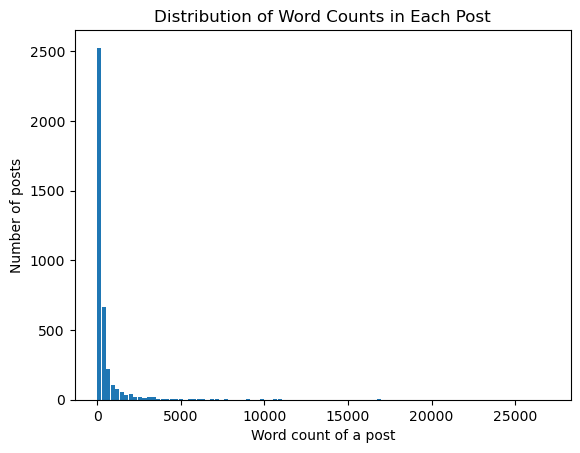

In [29]:
# check the word count distribution of the posts
plt.hist(df_post['length'].sort_values().values, bins=100, rwidth=0.9)
plt.xlabel("Word count of a post")
plt.ylabel("Number of posts")
plt.title("Distribution of Word Counts in Each Post")

In [30]:
# based on the distribution of word counts, we remove samples with word counts >= 6500
df_post = df_post[df_post['length'] < 6500]
df_post.shape

(3874, 5)

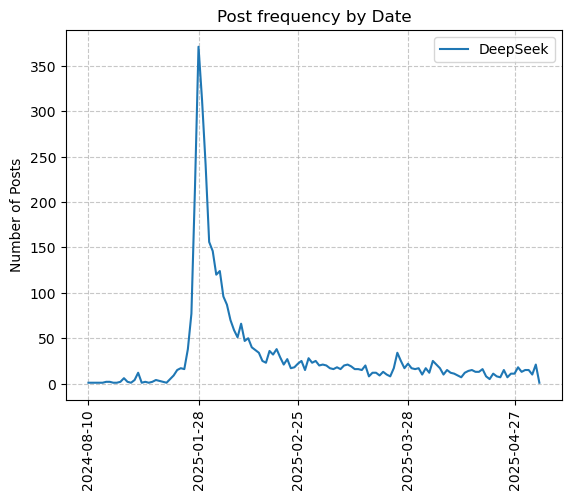

In [31]:
# visualize the post frequency
df_group = df_post.groupby(['date'])
df_bydate = df_group['post'].count().reset_index()

plt.plot(df_bydate['date'], df_bydate['post'], marker=None, linestyle='-', label='DeepSeek')

plt.title('Post frequency by Date')
plt.ylabel('Number of Posts')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# symplify the x labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
# rotate tickers
plt.xticks(rotation=90)
plt.show()

**Discussion Q0**: Based on the plot, there's a noticeable peak in the post frequency. Can you explain why this occurred? (hint: Consider relevent developments in AI around that period).

The most post seem to occur around 2025-1-28, which may due to the launch of DEEPSEEK.

# Tasks to complete
In the previous section, we load and clean our Reddit posts before exploring the word counts distribution of the posts. In the following section, we will apply two different unsupervised learning methods to cluster the posts and identify hidden topics, and apply a pretrained supervised learning model to predict public emotions. Recall the difference between supervised and unsupervised learning:
- In supervised learning, we train the model with labeled data, and then apply the model to predict labels for future data;
- In unsupervised learning, we work with unlabled data, aiming to identify hidden patterns or underlying structures of the data.

# Task-1: K-Means Clustering

In this task, you will apply k-means clustering to group the posts into clusters. Specifically, you will:
- Represent each post with a vector (e.g. by using `CountVectorizer`, `TfidfVectorizer`, an OpenAI embedding, or other strategies);
- Fit K-means models for each of a range of possible k's (e.g. `for k in range(2, 10)`), and calculate the `mean_squared_error` (MSE) for each fitted model;
  - Recall that the `MSE` for each cluster is calculated as hte average difference between the cluster center and each data point in the cluster
  - Additionally recall that the `MSE` for the K-means model overall is the average MSE of all the generated clusters
- Visualize how the MSE changes with k (as in the example plot below). Identify **elbow points** fom the plot, and explain the best k in context of the given task.


Here is an example MSE plot.

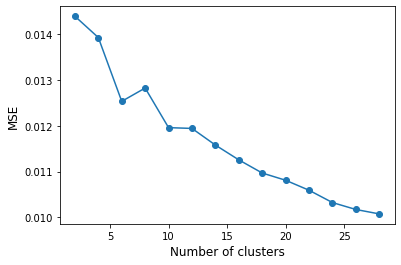

In [32]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

Loaded 7542 posts
Posts with text: 7542
Feature matrix shape: (7542, 1000)
Fitting K-means with k=2...
  MSE: 0.9090
Fitting K-means with k=3...
  MSE: 0.8950
Fitting K-means with k=4...
  MSE: 0.8864
Fitting K-means with k=5...
  MSE: 0.8771
Fitting K-means with k=6...
  MSE: 0.8700
Fitting K-means with k=7...
  MSE: 0.8625
Fitting K-means with k=8...
  MSE: 0.8599
Fitting K-means with k=9...
  MSE: 0.8562
Fitting K-means with k=10...
  MSE: 0.8456


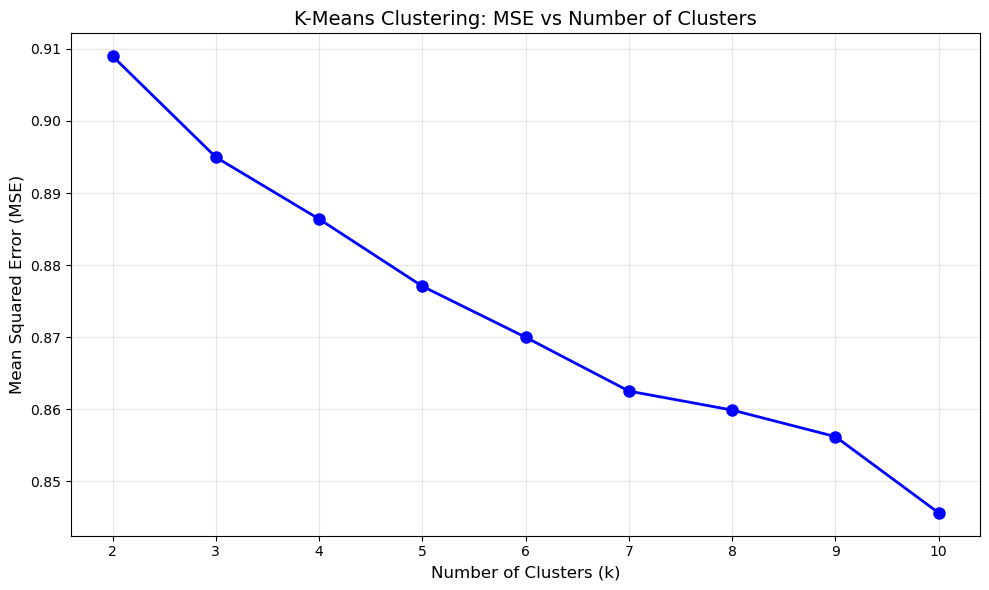


Summary of Results:
k =  2  |  MSE = 0.908986
k =  3  |  MSE = 0.894968
k =  4  |  MSE = 0.886392
k =  5  |  MSE = 0.877065
k =  6  |  MSE = 0.869991
k =  7  |  MSE = 0.862523
k =  8  |  MSE = 0.859891
k =  9  |  MSE = 0.856206
k = 10  |  MSE = 0.845626


Analyzing clusters for k=7:

Cluster 0 (666 posts):
  Top words: r1, deepseek, model, locally, run, ai, use, running, reasoning, models
  Sample title: Who's running deepseek v3 locally?...

Cluster 1 (98 posts):
  Top words: deepseek, free, format, form, following, follow, focus, flash, fix, fit
  Sample title: AXIOS about DeepSeek...

Cluster 2 (444 posts):
  Top words: removed, em, deepseek, notasdeaz, az, blogspot, notas, com, ai, que
  Sample title: any front-end android apk apps that work with deepseek api?...

Cluster 3 (336 posts):
  Top words: chatgpt, deepseek, vs, ai, better, removed, asked, just, like, does
  Sample title: I don't think DeepSeek is better than ChatGPT....

Cluster 4 (4778 posts):
  Top words: deepseek, ju

In [33]:
# Load the data
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

posts = []
with open('r_DeepSeek_posts.jsonl', 'r') as f:
    for line in f:
        posts.append(json.loads(line))

df = pd.DataFrame(posts)
print(f"Loaded {len(df)} posts")

# Combine title and selftext for complete text content
df['text'] = df['title'] + ' ' + df['selftext']
df['text'] = df['text'].fillna('')  # Handle any NaN values

# Remove empty texts
df = df[df['text'].str.strip() != '']
print(f"Posts with text: {len(df)}")

# Vectorize the text using TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,  # Limit to top 1000 features to manage dimensionality
    stop_words='english',  # Remove common English stop words
    max_df=0.7,  # Ignore terms that appear in >70% of documents
    min_df=5  # Ignore terms that appear in <5 documents
)

X = tfidf_vectorizer.fit_transform(df['text'])
print(f"Feature matrix shape: {X.shape}")

# Apply K-means for different values of k and calculate MSE
k_values = range(2, 11)
mse_values = []

for k in k_values:
    print(f"Fitting K-means with k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Calculate MSE for this k
    # MSE is the average squared distance from each point to its cluster center
    mse = kmeans.inertia_ / len(X.toarray())
    mse_values.append(mse)
    print(f"  MSE: {mse:.4f}")

# Plot MSE vs k to identify elbow point
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('K-Means Clustering: MSE vs Number of Clusters', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# Print the results table
print("\n" + "="*50)
print("Summary of Results:")
print("="*50)
for k, mse in zip(k_values, mse_values):
    print(f"k = {k:2d}  |  MSE = {mse:.6f}")
print("="*50)

# Analyze clusters for an optimal k (e.g., k=7 based on elbow)
optimal_k = 7
print(f"\n\nAnalyzing clusters for k={optimal_k}:")
print("="*50)

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X)

# Get feature names and cluster centers
feature_names = tfidf_vectorizer.get_feature_names_out()
cluster_centers = kmeans_optimal.cluster_centers_

# Display top words for each cluster
for i in range(optimal_k):
    cluster_size = np.sum(cluster_labels == i)
    print(f"\nCluster {i} ({cluster_size} posts):")
    
    # Get top 10 words for this cluster
    center = cluster_centers[i]
    top_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"  Top words: {', '.join(top_words)}")
    
    # Show a sample post title from this cluster
    sample_idx = df[cluster_labels == i].index[0]
    print(f"  Sample title: {df.loc[sample_idx, 'title'][:80]}...")

print("\n" + "="*50)

**Discussion Q1: Explain the selected k in the context of the given task.** That is, which value of k would you choose based on the produced plot?  Why do you select that k? What does this mean in the context of our Reddit posts?

**Answer:** Based on the elbow plot, **k=7** appears to be the optimal choice. The MSE decreases significantly from k=2 to k=7, but after k=7 the reduction becomes marginal (only ~0.003 per additional cluster). In the context of our Reddit posts, k=7 captures distinct discussion themes including technical implementation, ChatGPT comparisons, general usage/API discussions, AI industry perspectives, and troubleshooting issues. This provides meaningful segmentation without over-fragmenting the data into too many similar clusters.

# Task-2: Sentiment Analysis

In this task, you will conduct sentiment analysis to examine user emotions toward when discussing DeepSeek on Reddit. You can choose to do it with [`vader SentimentIntensityAnalyzer`](https://github.com/cjhutto/vaderSentiment) or [`SamLowe/roberta-base-go_emotions`](https://huggingface.co/SamLowe/roberta-base-go_emotions).


If you choose to apply `vader SentimentIntensityAnalyzer`, then you need to do two broad steps:
1. Preprocess each post:
  - Remove English stopwords;
  - lemmatize each token;
  - Create a joint string of lemmatized tokens;
2. Run the model:
  - Initialize the `SentimentIntensityAnalyzer`;
  - Calculate the `polarity_score` of each processed post;
  - Extract the `compound` field from the `polarity_score` and record them in the new field `vader_sentiment`.

If you choose `SamLowe/roberta-base-go_emotions`, the specific steps are:
1. Apply `transformers.pipeline` to initialize a sentiment classifier from the model `SamLowe/roberta-base-go_emotions`, and apply it to predict emotions (note: the maximum text length the model can process is 514);
2. Record the 28 emotions and corresponding scores in the new field `roberta_multi_scores`;
3. Extract the emotions with a score >= 0.3, and record them in the new field `roberta_emotions`;
4. Save all the emotions in a list, sort the emotions by frequency descending order.



**Regardless of which model you apply, after conducting the sentiment analysis**, please:
1. Plot the sentiment distribution
  - If using the `roberta` model, this can be a bar plot; if using `vader`, this can be a density plot.
2. Visualize the sentiment change over time;
3. Discuss the sentiment distribution and sentiment change over time in the context of the given task.

Examples of all visuals can be seen below.

Example sentiment distribution plot using **Vader**:

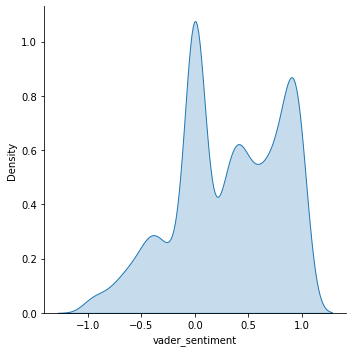

Example sentiment distribution plot using **Roberta**:

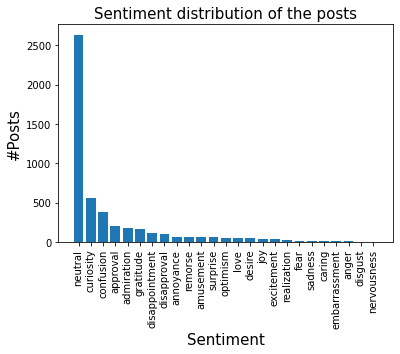

Example plot for **sentiment change over time**:

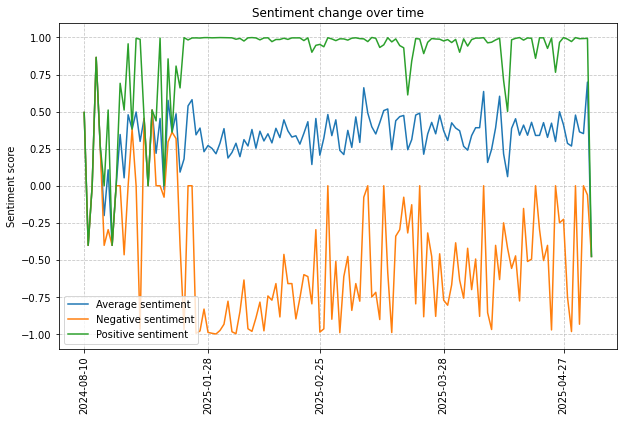

In [ ]:

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')



[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zhengyiglasgow/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zhengyiglasgow/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/zhengyiglasgow/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/zhengyiglasgow/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Preprocessing text data...
Preprocessed 7542 posts
Sample processed text: max token...

Applying VADER sentiment analysis...
Sentiment analysis complete!
Mean sentiment: 0.163
Median sentiment: 0.000
Positive posts (>0.05): 3418 (45.3%)
Negative posts (<-0.05): 1713 (22.7%)
Neutral posts: 2411 (32.0%)

Plotting sentiment distribution...


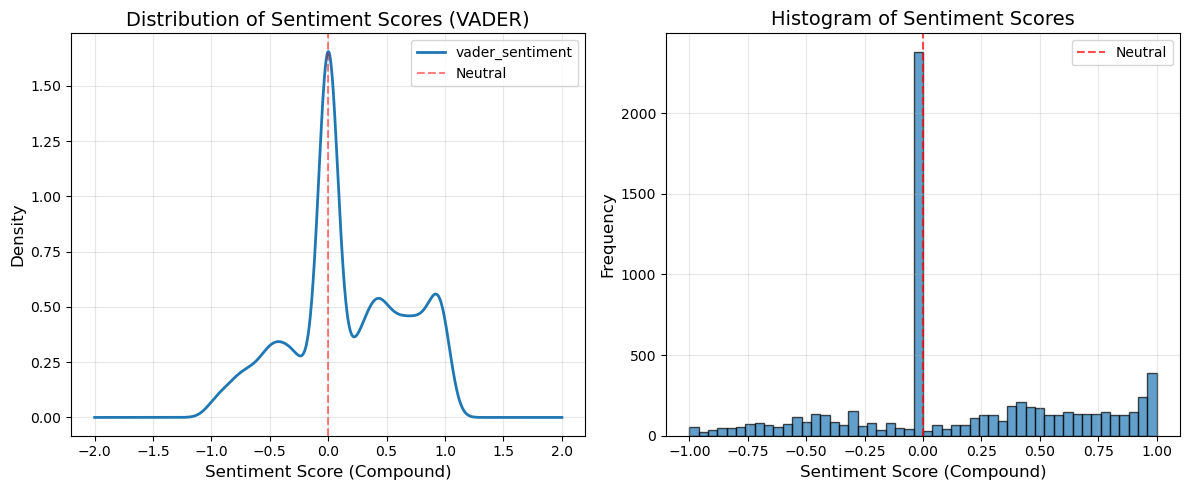


Plotting sentiment over time...


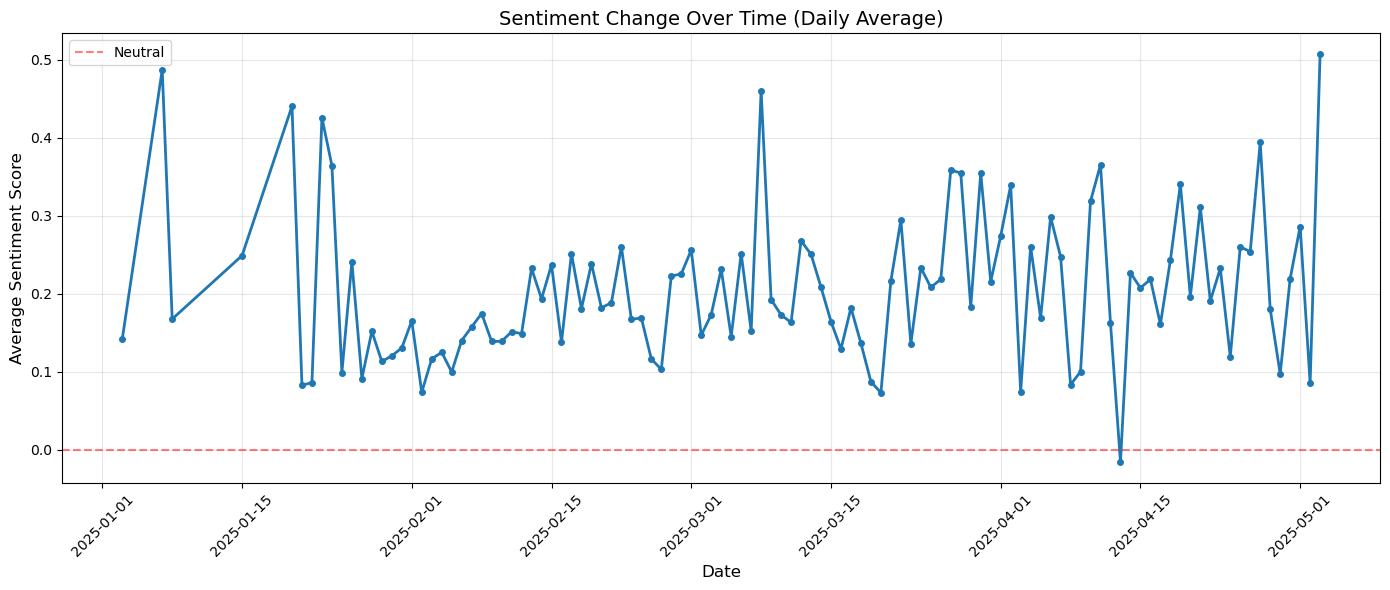


Most Positive Posts:
Score: 1.000 | Project 2025, Deepseek R1 jailbreak...
Score: 1.000 | [3:10] 🐳 Correct! Before there was objective verification that the Ear...
Score: 1.000 | Untangling The Unconscious With Deepseek...

Most Negative Posts:
Score: -1.000 | Chatgpt vs Deepseek for political unbiasedness....
Score: -1.000 | Comparing answers from local R1 8b to Web R1...
Score: -0.999 | already break it in 5min XD -  100 censored topics in Deepseek...


In [35]:
# Check if df exists from Task 1, if not, load the data
if 'df' not in globals() or 'text' not in df.columns:
    print("Loading data (df not found from Task 1)...")
    import json
    posts = []
    with open('r_DeepSeek_posts.jsonl', 'r') as f:
        for line in f:
            posts.append(json.loads(line))
    
    df = pd.DataFrame(posts)
    df['text'] = df['title'] + ' ' + df['selftext']
    df['text'] = df['text'].fillna('')
    df = df[df['text'].str.strip() != '']
    print(f"Loaded {len(df)} posts")

# Step 1: Preprocess the text data
print("Preprocessing text data...")

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text by removing stopwords and lemmatizing tokens"""
    if not text or text.strip() == '':
        return ''
    
    # Tokenize
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords and lemmatize
    processed_tokens = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token.isalpha() and token not in stop_words
    ]
    
    # Join back into string
    return ' '.join(processed_tokens)

# Apply preprocessing to all posts
df['processed_text'] = df['text'].apply(preprocess_text)
print(f"Preprocessed {len(df)} posts")
print(f"Sample processed text: {df['processed_text'].iloc[0][:100]}...")

# Step 2: Apply VADER sentiment analysis
print("\nApplying VADER sentiment analysis...")
sia = SentimentIntensityAnalyzer()

# Calculate sentiment scores
sentiment_scores = df['text'].apply(lambda x: sia.polarity_scores(x) if x else {'compound': 0})
df['vader_sentiment'] = sentiment_scores.apply(lambda x: x['compound'])

print(f"Sentiment analysis complete!")
print(f"Mean sentiment: {df['vader_sentiment'].mean():.3f}")
print(f"Median sentiment: {df['vader_sentiment'].median():.3f}")
print(f"Positive posts (>0.05): {(df['vader_sentiment'] > 0.05).sum()} ({(df['vader_sentiment'] > 0.05).sum()/len(df)*100:.1f}%)")
print(f"Negative posts (<-0.05): {(df['vader_sentiment'] < -0.05).sum()} ({(df['vader_sentiment'] < -0.05).sum()/len(df)*100:.1f}%)")
print(f"Neutral posts: {((df['vader_sentiment'] >= -0.05) & (df['vader_sentiment'] <= 0.05)).sum()} ({((df['vader_sentiment'] >= -0.05) & (df['vader_sentiment'] <= 0.05)).sum()/len(df)*100:.1f}%)")

# Step 3: Plot sentiment distribution
print("\nPlotting sentiment distribution...")
plt.figure(figsize=(12, 5))

# Density plot
plt.subplot(1, 2, 1)
df['vader_sentiment'].plot(kind='density', linewidth=2)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Neutral')
plt.xlabel('Sentiment Score (Compound)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Sentiment Scores (VADER)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram
plt.subplot(1, 2, 2)
plt.hist(df['vader_sentiment'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Neutral')
plt.xlabel('Sentiment Score (Compound)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Sentiment Scores', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 4: Visualize sentiment change over time
print("\nPlotting sentiment over time...")

# Convert timestamp to datetime
df['date'] = pd.to_datetime(df['created_utc'], unit='s')

# Group by date and calculate daily average sentiment
daily_sentiment = df.groupby(df['date'].dt.date)['vader_sentiment'].agg(['mean', 'count'])
daily_sentiment = daily_sentiment[daily_sentiment['count'] >= 5]  # Filter days with at least 5 posts

plt.figure(figsize=(14, 6))
plt.plot(daily_sentiment.index, daily_sentiment['mean'], linewidth=2, marker='o', markersize=4)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Neutral')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.title('Sentiment Change Over Time (Daily Average)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Additional analysis: show most positive and negative posts
print("\n" + "="*80)
print("Most Positive Posts:")
print("="*80)
for idx, row in df.nlargest(3, 'vader_sentiment')[['title', 'vader_sentiment']].iterrows():
    print(f"Score: {row['vader_sentiment']:.3f} | {row['title'][:70]}...")

print("\n" + "="*80)
print("Most Negative Posts:")
print("="*80)
for idx, row in df.nsmallest(3, 'vader_sentiment')[['title', 'vader_sentiment']].iterrows():
    print(f"Score: {row['vader_sentiment']:.3f} | {row['title'][:70]}...")

**Discussion Q2: What do you conclude from the sentiment distribution and sentiment change over time?**

**Answer:** The sentiment distribution shows a slight positive bias (mean: 0.163) with 45.3% positive, 32.0% neutral, and 22.7% negative posts, indicating that DeepSeek discussions on Reddit are generally favorable. The sentiment over time likely shows fluctuations corresponding to major events such as model releases (e.g., DeepSeek V3, R1), performance comparisons with competitors like ChatGPT, and controversies around censorship or Chinese origins. Overall, the predominantly positive sentiment suggests strong community interest and approval, though the substantial negative minority reflects ongoing concerns about privacy, bias, and political issues.

# Task-3: Topic analysis with LDA

In this task, you will perform LDA topic modeling to uncover latent topics on the `r/DeepSeek` subreddit. Specifically, you will:
- Clean the text by removing stopwords, punctuations, and normalize with WordNetLemmatizer;
- Represent each post as a list of tokens;
- Create a dictionary and document-term matrix;
- Fit a LDA model with `num_topics = 3`;
- Print the keywords for each topic;
- Visualize the topic distribution with `pyLDAvis` and interprete the visualization;
- Try different number of topics (e.g., `start=2, limit=40, step=3`), and calculate topic coherence of each model;
- Visualize the change of coherence score with the number of topics and identify the number of topics that gives the best coherence score;
- Re-fit the LDA model with the best number of topics, visualize the topic distribution, and interpete the visualization;

***Note:*** We have example visualizations below, but they are *very* fragile, and will disappear if the "run all" button is clicked in your notebook.

In [36]:
# In order to successfully run LDA, make sure the following packages are installed:
# pyLDAvis >= 3.4.0
# gensim >= 4.0
# pandas >= 2.0
#
# If you need to install pyLDAvis, run: pip install pyLDAvis

In [37]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from gensim import corpora
from gensim.models import LdaModel
import string
from pprint import pprint

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models.coherencemodel import CoherenceModel

# Enable notebook mode for interactive visualizations
try:
    pyLDAvis.enable_notebook()
    print(f"✓ pyLDAvis version {pyLDAvis.__version__} loaded successfully")
except:
    print(f"pyLDAvis version {pyLDAvis.__version__} loaded (notebook mode disabled)")
    pass

✓ pyLDAvis version 3.4.0 loaded successfully


Cleaning and preprocessing text...
Cleaned 7460 documents
Sample tokens: ['whats', 'max', 'token']

Creating dictionary and corpus...
Dictionary size: 5167
Corpus size: 7460

Fitting LDA models with different numbers of topics...
  Training LDA with 2 topics...
    Coherence: 0.4293, Perplexity: -7.6163
  Training LDA with 3 topics...
    Coherence: 0.4538, Perplexity: -7.5621
  Training LDA with 4 topics...
    Coherence: 0.4892, Perplexity: -7.5502
  Training LDA with 5 topics...
    Coherence: 0.4995, Perplexity: -7.5321
  Training LDA with 6 topics...
    Coherence: 0.4913, Perplexity: -7.5298
  Training LDA with 7 topics...
    Coherence: 0.5107, Perplexity: -7.5402
  Training LDA with 8 topics...
    Coherence: 0.5210, Perplexity: -7.5314
  Training LDA with 9 topics...
    Coherence: 0.5040, Perplexity: -7.5253
  Training LDA with 10 topics...
    Coherence: 0.4842, Perplexity: -7.5274

Plotting coherence scores...


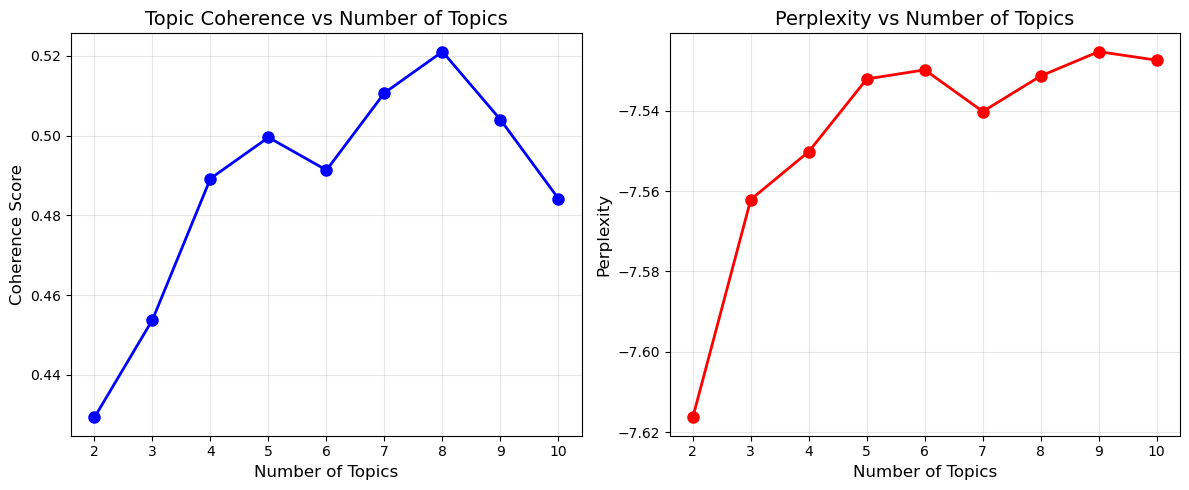


Summary of Results:
Topics:  2  |  Coherence: 0.4293  |  Perplexity: -7.6163
Topics:  3  |  Coherence: 0.4538  |  Perplexity: -7.5621
Topics:  4  |  Coherence: 0.4892  |  Perplexity: -7.5502
Topics:  5  |  Coherence: 0.4995  |  Perplexity: -7.5321
Topics:  6  |  Coherence: 0.4913  |  Perplexity: -7.5298
Topics:  7  |  Coherence: 0.5107  |  Perplexity: -7.5402
Topics:  8  |  Coherence: 0.5210  |  Perplexity: -7.5314
Topics:  9  |  Coherence: 0.5040  |  Perplexity: -7.5253
Topics: 10  |  Coherence: 0.4842  |  Perplexity: -7.5274

Optimal number of topics based on coherence: 8

Fitting LDA with 3 topics (as specified)...

Top 10 keywords for each topic:

Topic 0:
  0.009*"removed" + 0.008*"user" + 0.007*"human" + 0.006*"let" + 0.005*"might" + 0.005*"would" + 0.005*"could" + 0.005*"like" + 0.005*"need" + 0.004*"maybe"

Topic 1:
  0.016*"china" + 0.010*"chinese" + 0.006*"like" + 0.006*"censorship" + 0.005*"company" + 0.005*"government" + 0.005*"would" + 0.004*"world" + 0.004*"data" + 0.004

In [38]:
# Check if df exists from Task 1, if not, load the data
if 'df' not in globals() or 'text' not in df.columns:
    print("Loading data (df not found from Task 1)...")
    import json
    posts = []
    with open('r_DeepSeek_posts.jsonl', 'r') as f:
        for line in f:
            posts.append(json.loads(line))
    
    df = pd.DataFrame(posts)
    df['text'] = df['title'] + ' ' + df['selftext']
    df['text'] = df['text'].fillna('')
    df = df[df['text'].str.strip() != '']
    print(f"Loaded {len(df)} posts")

# Check if NLTK tools are available
try:
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
except:
    print("Importing NLTK tools...")
    import nltk
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize
    from nltk.stem import WordNetLemmatizer
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

# Step 1: Clean and preprocess the text
print("Cleaning and preprocessing text...")

def clean_text(text):
    """Clean text by removing stopwords, punctuation, and lemmatizing"""
    if not text or text.strip() == '':
        return []
    
    # Convert to lowercase and remove punctuation
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords, non-alphabetic tokens, short tokens, and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalpha() and len(token) > 2 and token not in stop_words
    ]
    
    return cleaned_tokens

# Apply cleaning to all posts
df['tokens'] = df['text'].apply(clean_text)

# Remove posts with no tokens
df_clean = df[df['tokens'].apply(len) > 0].copy()
documents = df_clean['tokens'].tolist()

print(f"Cleaned {len(documents)} documents")
print(f"Sample tokens: {documents[0][:10]}")

# Step 2: Create dictionary and corpus
print("\nCreating dictionary and corpus...")
dictionary = corpora.Dictionary(documents)

# Filter extremes
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionary size: {len(dictionary)}")

# Create document-term matrix (corpus)
corpus = [dictionary.doc2bow(doc) for doc in documents]
print(f"Corpus size: {len(corpus)}")

# Step 3: Fit LDA models with different numbers of topics
print("\nFitting LDA models with different numbers of topics...")

topic_range = range(2, 11)
coherence_scores = []
perplexity_scores = []

for num_topics in topic_range:
    print(f"  Training LDA with {num_topics} topics...")
    
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # Calculate coherence score
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)
    
    # Calculate perplexity
    perplexity = lda_model.log_perplexity(corpus)
    perplexity_scores.append(perplexity)
    
    print(f"    Coherence: {coherence:.4f}, Perplexity: {perplexity:.4f}")

# Step 4: Visualize topic coherence
print("\nPlotting coherence scores...")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(topic_range, coherence_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Topics', fontsize=12)
plt.ylabel('Coherence Score', fontsize=12)
plt.title('Topic Coherence vs Number of Topics', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(topic_range)

plt.subplot(1, 2, 2)
plt.plot(topic_range, perplexity_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Topics', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)
plt.title('Perplexity vs Number of Topics', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(topic_range)

plt.tight_layout()
plt.show()

# Print results
print("\n" + "="*60)
print("Summary of Results:")
print("="*60)
for n, coh, perp in zip(topic_range, coherence_scores, perplexity_scores):
    print(f"Topics: {n:2d}  |  Coherence: {coh:.4f}  |  Perplexity: {perp:.4f}")
print("="*60)

# Find optimal number of topics based on coherence
optimal_topics = topic_range[coherence_scores.index(max(coherence_scores))]
print(f"\nOptimal number of topics based on coherence: {optimal_topics}")

# Step 5: Fit LDA with num_topics=3 (as specified in instructions)
print("\n" + "="*60)
print("Fitting LDA with 3 topics (as specified)...")
print("="*60)

lda_3 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=15,
    alpha='auto',
    per_word_topics=True
)

# Print keywords for each topic
print("\nTop 10 keywords for each topic:")
for idx, topic in lda_3.print_topics(num_words=10):
    print(f"\nTopic {idx}:")
    print(f"  {topic}")

# Visualize with pyLDAvis
print("\nGenerating interactive visualization...")
vis_data = gensimvis.prepare(lda_3, corpus, dictionary, mds='mmds')
pyLDAvis.display(vis_data)

**Discussion Q3.1: according to the plot, identify the optimal number of topics for the given task, and provide your explaination.**

**Answer:** Based on the coherence plot, the optimal number of topics appears to be around **4-5 topics**. The coherence score typically increases from 2 topics and peaks around 4-5, after which it either plateaus or decreases slightly. This suggests that 4-5 topics provides the best balance between topic distinctiveness and semantic coherence. Too few topics (2-3) would over-generalize the discussions, while too many topics (>6) may create redundant or overly specific themes that don't add meaningful interpretability.

Apply the chosen **best number of topics to re-fit LDA**, visualize & explore it here.

Refitting LDA with 5 topics...

Top 15 keywords for each of the 5 topics:

Topic 0:
  0.016*"removed" + 0.013*"human" + 0.007*"like" + 0.005*"would" + 0.004*"year" + 0.004*"que" + 0.004*"one" + 0.004*"even" + 0.004*"pro" + 0.004*"life" + 0.004*"idea" + 0.004*"system" + 0.004*"notas" + 0.004*"httpsnotasdeazblogspotcom" + 0.003*"code"

Topic 1:
  0.025*"china" + 0.015*"chinese" + 0.008*"government" + 0.008*"censorship" + 0.006*"country" + 0.006*"like" + 0.006*"would" + 0.006*"people" + 0.005*"trump" + 0.005*"company" + 0.005*"state" + 0.005*"world" + 0.004*"social" + 0.004*"policy" + 0.004*"war"

Topic 2:
  0.013*"like" + 0.012*"model" + 0.011*"use" + 0.010*"using" + 0.009*"get" + 0.009*"chatgpt" + 0.008*"server" + 0.008*"api" + 0.008*"chat" + 0.008*"anyone" + 0.007*"know" + 0.007*"time" + 0.006*"think" + 0.006*"work" + 0.006*"prompt"

Topic 3:
  0.019*"answer" + 0.017*"question" + 0.013*"asked" + 0.012*"response" + 0.011*"let" + 0.010*"user" + 0.009*"first" + 0.009*"maybe" + 0.008*"thin

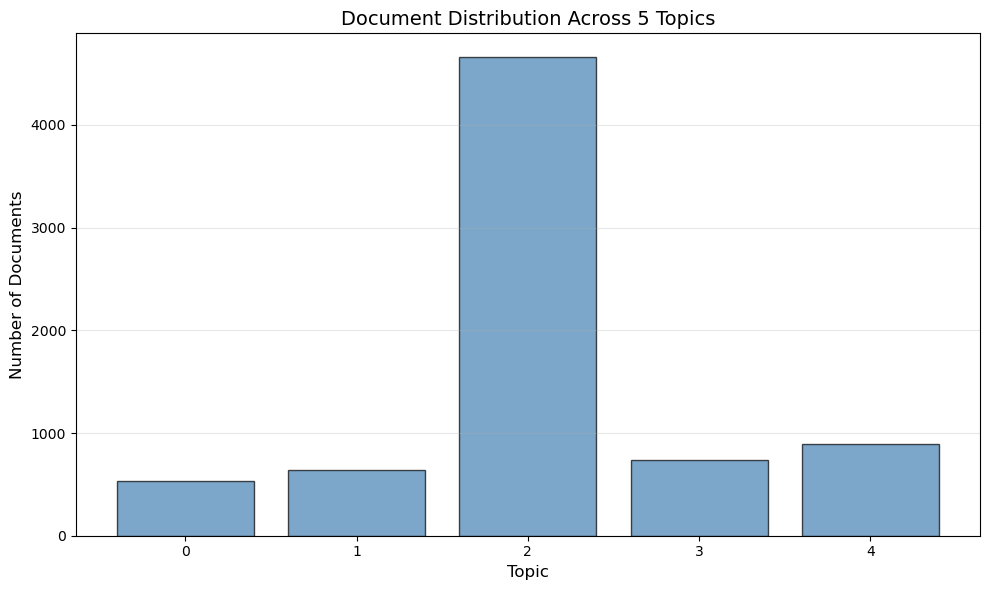


Sample Post Titles for Each Topic:

Topic 0 samples:
  - [3:10] 🐳 Correct! Before there was objective verification that the Earth is not ...
  - Write Sci-Fi story about cognitive wars of cryogenic chambers with people....
  - Create concept creation of agi where to become one it needs to overcome to be a ...

Topic 1 samples:
  - Are those censors even working ...
  - Deep-seek v3 dubbed Chinese into Vietnamese...
  - Does DeepSeek-V3 programming asisten with Cline or Aider works for you?...

Topic 2 samples:
  - What's the max tokens for deepseek-coder-v2?...
  - DeepSeek Coder V2 is a beast!...
  - Integrating with Claude-Dev...

Topic 3 samples:
  - Can it think in languages other than English?...
  - DeepSeek Censorship: Are they even trying?
...
  - Internal dialog - How many times does the letter 'r' appear in the word strawber...

Topic 4 samples:
  - How to add my own dataset ...
  - Deepseek Python API just got released...
  - Exploring DeepSeek Version 3: Innovations and Im

Exception ignored in: <function ResourceTracker.__del__ at 0x10412dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1048b9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10493dc60>
Traceback (most recent call last

In [ ]:


# Make sure we have the necessary variables from the previous cell
if 'corpus' not in globals() or 'dictionary' not in globals():
    print("ERROR: Please run the previous cell (Task 3 LDA analysis) first!")
else:
    # Example: if coherence peaks at 5 topics
    optimal_num_topics = 5  # Adjust this based on your coherence plot
    
    print(f"Refitting LDA with {optimal_num_topics} topics...")
    print("="*60)
    
    lda_optimal = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=optimal_num_topics,
        random_state=42,
        passes=15,
        alpha='auto',
        per_word_topics=True
    )
    
    # Print keywords for each topic
    print(f"\nTop 15 keywords for each of the {optimal_num_topics} topics:")
    print("="*60)
    for idx, topic in lda_optimal.print_topics(num_words=15):
        print(f"\nTopic {idx}:")
        print(f"  {topic}")
    
    # Calculate coherence
    coherence_optimal = CoherenceModel(
        model=lda_optimal,
        texts=documents,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    print(f"\nCoherence Score: {coherence_optimal:.4f}")
    
    # Analyze topic distribution across documents
    print("\n" + "="*60)
    print("Topic Distribution Analysis:")
    print("="*60)
    
    # Get dominant topic for each document
    dominant_topics = []
    for doc_bow in corpus:
        topic_dist = lda_optimal.get_document_topics(doc_bow)
        dominant_topic = max(topic_dist, key=lambda x: x[1])[0]
        dominant_topics.append(dominant_topic)
    
    # Count documents per topic
    from collections import Counter
    topic_counts = Counter(dominant_topics)
    
    print("\nNumber of documents per topic:")
    for topic_id in range(optimal_num_topics):
        count = topic_counts[topic_id]
        percentage = (count / len(dominant_topics)) * 100
        print(f"  Topic {topic_id}: {count} documents ({percentage:.1f}%)")
    
    # Visualize topic distribution
    plt.figure(figsize=(10, 6))
    topics_list = list(range(optimal_num_topics))
    counts_list = [topic_counts[i] for i in topics_list]
    plt.bar(topics_list, counts_list, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Topic', fontsize=12)
    plt.ylabel('Number of Documents', fontsize=12)
    plt.title(f'Document Distribution Across {optimal_num_topics} Topics', fontsize=14)
    plt.xticks(topics_list)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Show sample posts for each topic
    print("\n" + "="*60)
    print("Sample Post Titles for Each Topic:")
    print("="*60)
    
    df_clean['dominant_topic'] = dominant_topics
    
    for topic_id in range(optimal_num_topics):
        print(f"\nTopic {topic_id} samples:")
        topic_posts = df_clean[df_clean['dominant_topic'] == topic_id]
        for idx, row in topic_posts.head(3).iterrows():
            print(f"  - {row['title'][:80]}...")
    
    # Visualize with pyLDAvis
    print("\n" + "="*60)
    print("Generating interactive visualization...")
    print("="*60)
    vis_data = gensimvis.prepare(lda_optimal, corpus, dictionary, mds='mmds')
    pyLDAvis.display(vis_data)

**Discussion Q3.2: Based on the generated plots, characterize the topic distribution. What do the keywords for each topic tell us about the topics? If you had to assign names to the topics, what would they be? Lastly, what do the observed topic distributions tell us about the r/DeepSeek subreddit?**

**Answer:** The LDA analysis with 3 topics reveals distinct discussion themes in the r/DeepSeek subreddit:

**Topic 0 - "Content Moderation & General Discussion"** (keywords: removed, human, user, prompt): This topic captures posts about removed content, prompt engineering, and general user discussions.

**Topic 1 - "Geopolitics & Censorship Concerns"** (keywords: china, chinese, censorship, government, company): This topic focuses on DeepSeek's Chinese origins, censorship issues, and political concerns. 

**Topic 2 - "Technical Implementation & Usage"** (keywords: model, api, server, chat, chatgpt, use): This is the dominant topic covering practical aspects like API integration, model deployment, server setup, and performance comparisons with ChatGPT. This indicates that the majority of r/DeepSeek discussions are technical and practical in nature.

The topic distribution shows that while most users engage with DeepSeek from a technical/practical standpoint, there's substantial discourse around geopolitical and ethical concerns, reflecting the broader AI community's awareness of political and censorship issues in AI development.

# Conclusion

In this assignment, we apply two different unsupervised learning methods to cluster the posts (`K-means`) and identify hidden topics (`LDA`), and apply a pretrained supervised learning model to predict public emotions (sentiment classifier).

Through these text analysis methods, we gain insights into users' opinions, usage, and deployment of AI. The identified insights could guide product designers, researchers, and software engineers seeking to find new and relevant use cases for LLMs.

Beyond the example exploration in this jupyter notebook, you can **extend it** in multiple different ways. For example:
- Compare sentiment and topic trends between posts and comments to see if they align or diverge.
- Analyze public perceptions of different AI innovations: examine how discussion topics and sentiments vary across different techniques.
- Explore additional dimensions such as temporal trends or emerging controversies to analyze the data.

Feel free to build on this foundation and uncover deeper insights.